<a href="https://colab.research.google.com/github/Ashishjoshi794/computer-vision/blob/main/linear_nn_for_image.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [52]:
import tensorflow as tf
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import os

In [89]:
IMG_HEIGHT = 254
IMG_WIDTH = 254
IMG_CHANNELS = 3
CLASS_NAMES = ["daisy", "dandelion", "roses", "sunflowers", "tulips"]


In [90]:
def read_and_decode(filename, resize_dims):
    # 1. Read the raw file
    img_bytes = tf.io.read_file(filename)
    # 2. Decode image data
    img = tf.image.decode_jpeg(img_bytes, channels=IMG_CHANNELS)
    # 3. Convert pixel values to floats in [0, 1]
    img = tf.image.convert_image_dtype(img, tf.float32)
    # 4. Resize the image to match desired dimensions
    img = tf.image.resize(img, resize_dims)
    return img

In [91]:
def parse_csvline(csv_line):
    # record_defaults specify the data types for each column
    record_default = ["", ""]
    filename, label_string = tf.io.decode_csv(csv_line, record_default)

    # Load the image
    img = read_and_decode(filename, [IMG_HEIGHT, IMG_WIDTH])

    # Convert label string to integer based on the CLASS_NAMES index
    label = tf.argmax(tf.math.equal(CLASS_NAMES, label_string))
    return img, label

In [115]:
import tensorflow as tf

read_and_decode= "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

data_dir = tf.keras.utils.get_file(
    "flower_photos",
    origin=read_and_decode,
    untar=True
)

In [120]:
import os

print(os.listdir(data_dir))

['flower_photos']


In [121]:
data_dir = os.path.join(data_dir, "flower_photos")

print(os.listdir(data_dir))

['roses', 'sunflowers', 'tulips', 'daisy', 'LICENSE.txt', 'dandelion']


In [122]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(254, 254),
    batch_size=16
)

eval_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(254, 254),
    batch_size=16
)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.


In [128]:
for image_batch, label_batch in train_dataset.take(2):
    print("Image batch shape:", image_batch.shape)
    print("Label batch shape:", label_batch.shape)
    print("Labels:", label_batch.numpy())

Image batch shape: (16, 254, 254, 3)
Label batch shape: (16,)
Labels: [4 0 2 1 1 0 4 3 4 1 1 0 1 1 0 4]
Image batch shape: (16, 254, 254, 3)
Label batch shape: (16,)
Labels: [4 2 0 1 1 4 1 0 2 4 1 3 0 3 0 1]


Normalization


In [129]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_dataset = train_dataset.map(
    lambda images, labels: (normalization_layer(images), labels)
)

eval_dataset = eval_dataset.map(
    lambda images, labels: (normalization_layer(images), labels)
)

In [131]:
for image_batch, label_batch in train_dataset.take(1):
    print("Image shape:", image_batch.shape)
    print("Min:", tf.reduce_min(image_batch).numpy())
    print("Max:", tf.reduce_max(image_batch).numpy())

Image shape: (16, 254, 254, 3)
Min: 0.0
Max: 1.0


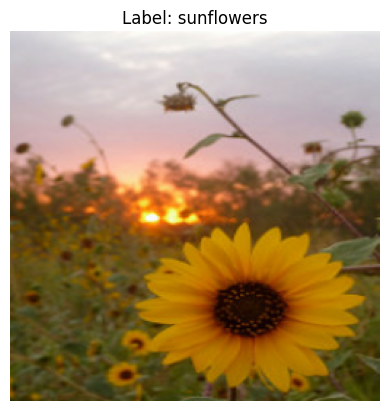

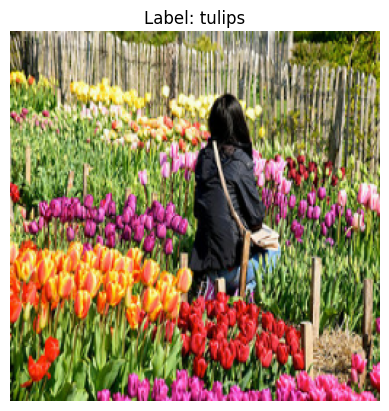

In [130]:
import matplotlib.pyplot as plt

for image_batch, label_batch in train_dataset.take(2):
    # Take the first image from the batch
    first_image = image_batch[0]
    first_label = label_batch[0]

    # Convert tensor to numpy array
    plt.imshow(first_image.numpy())
    plt.title(f"Label: {CLASS_NAMES[first_label]}")
    plt.axis('off')
    plt.show()

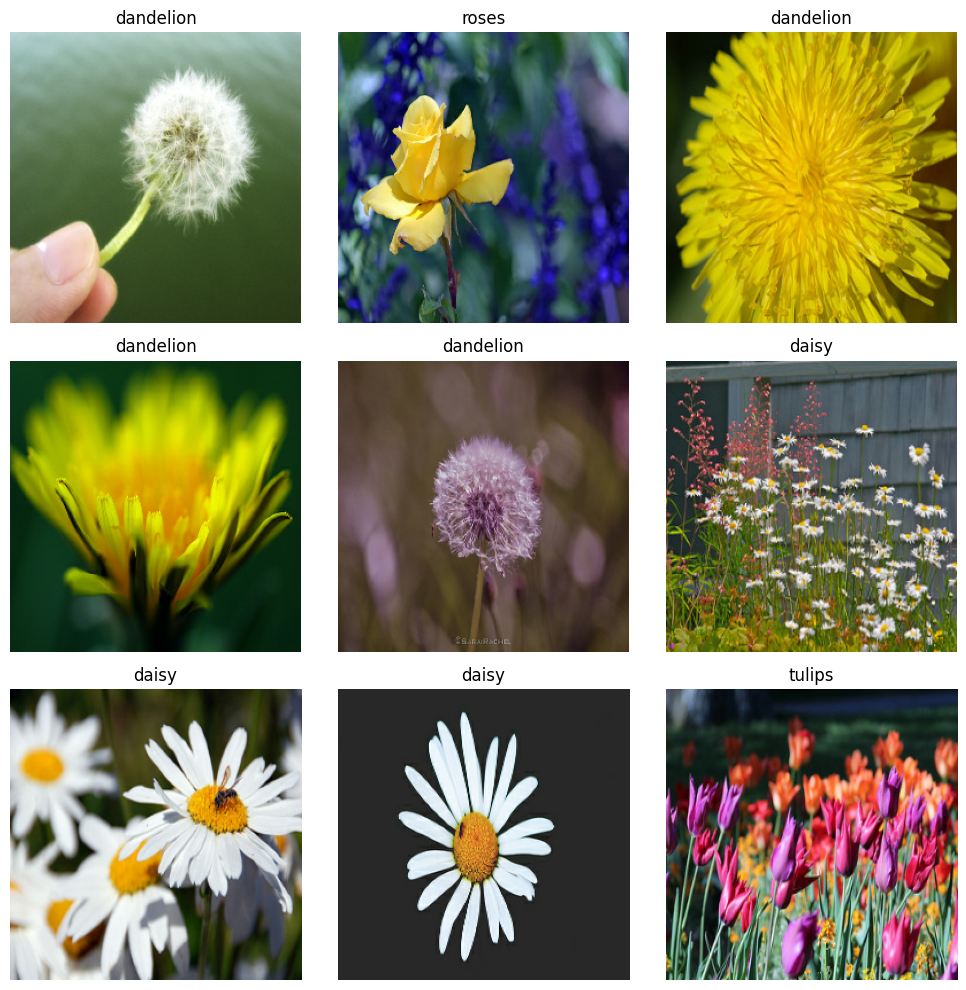

In [135]:
plt.figure(figsize=(10, 10))
for i, (image_batch, label_batch) in enumerate(train_dataset.take(1)):
    for j in range(9):
        plt.subplot(3, 3, j + 1)
        plt.imshow(image_batch[j].numpy())
        plt.title(CLASS_NAMES[label_batch[j]])
        plt.axis('off')
    break # Only take one batch to display 9 images
plt.tight_layout()
plt.show()

In [137]:
from tensorflow import keras

model = keras.Sequential([
    keras.layers.Flatten(input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)),
    keras.layers.Dense(len(CLASS_NAMES), activation="softmax")
])

model.compile(
    optimizer="adam",
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"]
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [138]:
EPOCHS = 10

history = model.fit(
    train_dataset,
    validation_data=eval_dataset,
    epochs=EPOCHS
)

Epoch 1/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 11s 50ms/step - accuracy: 0.3396 - loss: 20.3911 - val_accuracy: 0.4251 - val_loss: 9.8669
Epoch 2/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.4193 - loss: 13.0230 - val_accuracy: 0.3937 - val_loss: 13.6951
Epoch 3/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step - accuracy: 0.4612 - loss: 11.1680 - val_accuracy: 0.3460 - val_loss: 23.1657
Epoch 4/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.4714 - loss: 13.3331 - val_accuracy: 0.3474 - val_loss: 18.3451
Epoch 5/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.4901 - loss: 13.0554 - val_accuracy: 0.3992 - val_loss: 20.1666
Epoch 6/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.5170 - loss: 12.2047 - val_accuracy: 0.3924 - val_loss: 14.4809
Epoch 7/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.5596 - loss: 9.8637 - val_accuracy: 0.3569 - val_loss: 17.1376
Epoch 8/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - accuracy: 0.5484 - loss: 11

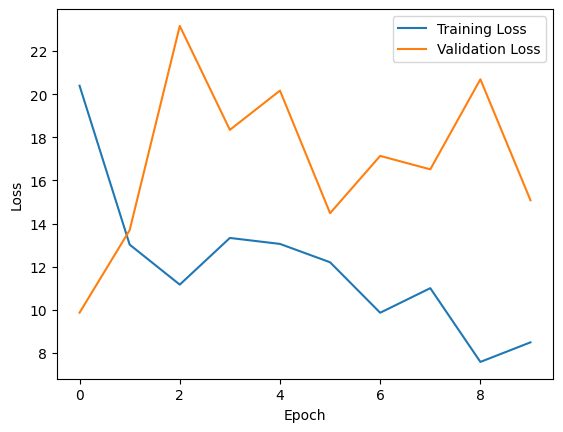

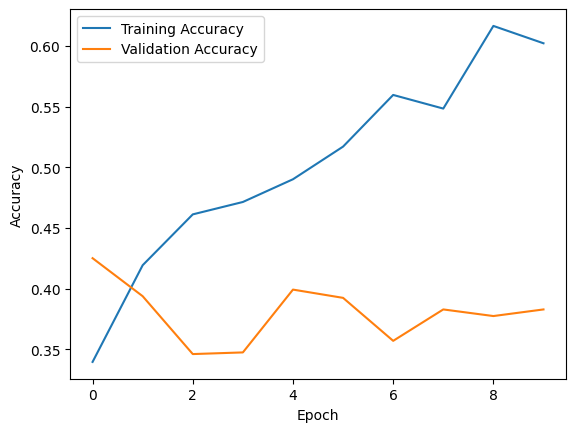

In [139]:
import matplotlib.pyplot as plt

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()